# **Rossmann Store Sales**

In [1]:
import pandas as pd

In [2]:
ross_df = pd.read_csv(r'D:\ML Belajarrrr\GradianBoosting\RossmannData\train.csv')
store_df = pd.read_csv(r'D:\ML Belajarrrr\GradianBoosting\RossmannData\store.csv')
test_df = pd.read_csv(r'D:\ML Belajarrrr\GradianBoosting\RossmannData\test.csv')
submission_df = pd.read_csv(r'D:\ML Belajarrrr\GradianBoosting\RossmannData\sample_submission.csv')

C:\Users\HELWA\AppData\Local\Temp\ipykernel_14544\1434638088.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  ross_df = pd.read_csv(r'D:\ML Belajarrrr\GradianBoosting\RossmannData\train.csv')


In [3]:
ross_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [4]:
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [5]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [6]:
submission_df

,Id,Sales
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
41083,41084,0
41084,41085,0
41085,41086,0
41086,41087,0


## **Merge Data**

In [7]:
merged_df = ross_df.merge(store_df, how='left', on='Store')
merged_test_df = test_df.merge(store_df, how='left', on='Store')

In [8]:
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


## **Preprocessing and Feature Engineering**

In [9]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

### **Date**

In [10]:
# Convert Date to a datecolumn and extract different parts of the date.
def split_date(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df.Date.dt.year
    df['Month'] = df.Date.dt.month
    df['Day'] = df.Date.dt.day
    df['WeekOfYear'] = df.Date.dt.isocalendar().week
    

In [11]:
split_date(merged_df)
split_date(merged_test_df)

In [12]:
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,...,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",2013,1,1,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,...,4.0,2006.0,0,NaN,NaN,NaN,2013,1,1,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,...,NaN,NaN,0,NaN,NaN,NaN,2013,1,1,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,...,NaN,NaN,0,NaN,NaN,NaN,2013,1,1,1


### **Store Open/Closed**

In [13]:
# Cek penjualan ketika toko tutup
merged_df[merged_df.Open == 0].Sales.value_counts()

# Penjelasan output:
# Ada 172.817 baris data di mana toko tutup, dan pada saat itu jumlah penjualannya adalah 0

Sales
0    172817
Name: count, dtype: int64

In [14]:
merged_df = merged_df[merged_df.Open == 1].copy()

### **Competition**
Use the columns CompetitionOpenSince[Month/Year] columns from store_df to compute the number of months for which a competitor has been open near the store.

In [15]:
def comp_month(df):
    df['CompetitionOpen'] = 12 * (df.Year - df.CompetitionOpenSinceYear) +  (df.Month - df.CompetitionOpenSinceMonth)
    df['CompetitionOpen'] = df['CompetitionOpen'].map(lambda x: 0 if x < 0 else x).fillna(0)

In [16]:
comp_month(merged_df)
comp_month(merged_test_df)

In [17]:
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear,CompetitionOpen
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,2008.0,0,NaN,NaN,NaN,2015,7,31,31,82.0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,92.0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,103.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,2009.0,0,NaN,NaN,NaN,2015,7,31,31,70.0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,2015.0,0,NaN,NaN,NaN,2015,7,31,31,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1,b,...,2006.0,0,NaN,NaN,NaN,2013,1,1,1,76.0
1016827,733,2,2013-01-01,10765,2377,1,0,a,1,b,...,1999.0,0,NaN,NaN,NaN,2013,1,1,1,159.0
1016863,769,2,2013-01-01,5035,1248,1,0,a,1,b,...,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013,1,1,1,0.0
1017042,948,2,2013-01-01,4491,1039,1,0,a,1,b,...,NaN,0,NaN,NaN,NaN,2013,1,1,1,0.0


### **Additional Promotion**

In [18]:
def check_promo_month(row):
    month2str = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 
                 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sept', 10: 'Oct',
                 11: 'Nov', 12: 'Dec'}
    
    try:
        months = (row['PromoInterval'] or '').split(',')
        if row['Promo2Open'] and month2str[row['Month']] in months:
            return 1
        else:
            return 0
    except Exception:
        return 0

def promo_cols(df):
    # Months since Promo2 was open
    df['Promo2Open'] = 12 * (df.Year - df.Promo2SinceYear) +  (df.WeekOfYear - df.Promo2SinceWeek)*7/30.5
    df['Promo2Open'] = df['Promo2Open'].map(lambda x: 0 if x < 0 else x).fillna(0) * df['Promo2']
    # Whether a new round of promotions was started in the current month
    df['IsPromo2Month'] = df.apply(check_promo_month, axis=1) * df['Promo2']

In [19]:
promo_cols(merged_df)
promo_cols(merged_test_df)

In [20]:
merged_df[['Date', 'Promo2', 'Promo2SinceYear', 'Promo2SinceWeek', 'PromoInterval', 'Promo2Open', 'IsPromo2Month']].sample(20)

,Date,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,Promo2Open,IsPromo2Month
838072,2013-06-10,0,NaN,NaN,NaN,0.000000,0
997722,2013-01-18,0,NaN,NaN,NaN,0.000000,0
773340,2013-08-07,0,NaN,NaN,NaN,0.000000,0
679229,2013-10-31,0,NaN,NaN,NaN,0.000000,0
984216,2013-01-30,1,2013.0,31.0,"Jan,Apr,Jul,Oct",0.000000,0
692428,2013-10-19,0,NaN,NaN,NaN,0.000000,0
512926,2014-03-29,0,NaN,NaN,NaN,0.000000,0
593031,2014-01-16,1,2009.0,31.0,"Feb,May,Aug,Nov",53.573770,0
362260,2014-08-19,1,2014.0,10.0,"Jan,Apr,Jul,Oct",5.508197,0
758391,2013-08-21,1,2010.0,13.0,"Jan,Apr,Jul,Oct",40.819672,0


### **Input and Target Columns**

In [21]:
merged_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day',
       'WeekOfYear', 'CompetitionOpen', 'Promo2Open', 'IsPromo2Month'],
      dtype='object')

In [22]:
input_cols = ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday', 
              'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpen', 
              'Day', 'Month', 'Year', 'WeekOfYear',  'Promo2', 
              'Promo2Open', 'IsPromo2Month']
target_col = 'Sales'

In [23]:
inputs = merged_df[input_cols].copy()
targets = merged_df[target_col].copy()

In [24]:
test_inputs = merged_test_df[input_cols].copy()

In [25]:
inputs

,Store,DayOfWeek,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpen,Day,Month,Year,WeekOfYear,Promo2,Promo2Open,IsPromo2Month
0,1,5,1,0,1,c,a,1270.0,82.0,31,7,2015,31,0,0.000000,0
1,2,5,1,0,1,a,a,570.0,92.0,31,7,2015,31,1,64.131148,1
2,3,5,1,0,1,a,a,14130.0,103.0,31,7,2015,31,1,51.901639,1
3,4,5,1,0,1,c,c,620.0,70.0,31,7,2015,31,0,0.000000,0
4,5,5,1,0,1,a,a,29910.0,3.0,31,7,2015,31,0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,0,a,1,b,a,150.0,76.0,1,1,2013,1,0,0.000000,0
1016827,733,2,0,a,1,b,b,860.0,159.0,1,1,2013,1,0,0.000000,0
1016863,769,2,0,a,1,b,b,840.0,0.0,1,1,2013,1,1,1.213115,1
1017042,948,2,0,a,1,b,b,1430.0,0.0,1,1,2013,1,0,0.000000,0


In [26]:
numeric_cols = ['Store', 'Promo', 'SchoolHoliday',
                'CompetitionDistance', 'CompetitionOpen', 'Promo2', 'Promo2Open',
                'Day', 'Month', 'Year', 'WeekOfYear']
categorical_cols = ['DayOfWeek', 'StateHoliday', 'StoreType', 'Assortment']

### **Impute Missing Numerical Data**

In [27]:
inputs[numeric_cols].isna().sum()

Store                     0
Promo                     0
SchoolHoliday             0
CompetitionDistance    2186
CompetitionOpen           0
Promo2                    0
Promo2Open                0
Day                       0
Month                     0
Year                      0
WeekOfYear                0
dtype: int64

In [28]:
test_inputs[numeric_cols].isna().sum()

Store                   0
Promo                   0
SchoolHoliday           0
CompetitionDistance    96
CompetitionOpen         0
Promo2                  0
Promo2Open              0
Day                     0
Month                   0
Year                    0
WeekOfYear              0
dtype: int64

In [30]:
max_distance = inputs.CompetitionDistance.max()
max_distance

np.float64(75860.0)

In [31]:
inputs['CompetitionDistance'].fillna(max_distance, inplace=True)
test_inputs['CompetitionDistance'].fillna(max_distance, inplace=True)

C:\Users\HELWA\AppData\Local\Temp\ipykernel_14544\751725973.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  inputs['CompetitionDistance'].fillna(max_distance, inplace=True)
C:\Users\HELWA\AppData\Local\Temp\ipykernel_14544\751725973.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

### **Scale Numeric Values**

In [32]:
from sklearn.preprocessing import MinMaxScaler

In [33]:
scaler = MinMaxScaler().fit(inputs[numeric_cols])

In [34]:
inputs[numeric_cols] = scaler.transform(inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

### **Encode Categorical Colums**

In [35]:
from sklearn.preprocessing import OneHotEncoder

In [48]:
# Menjadikan categorical_cols menjadi string semua
inputs[categorical_cols] = inputs[categorical_cols].fillna('Unknown').astype(str)
test_inputs[categorical_cols] = test_inputs[categorical_cols].fillna('Unknown').astype(str)

In [49]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [50]:
inputs[encoded_cols] = encoder.transform(inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

In [51]:
X = inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

### **Gradient Boosting**

Konsep Dasar Gradient Boosting Machine (GBM)
1. Gradient Boosting adalah salah satu algoritma ensemble learning yang sangat kuat, yang bekerja dengan prinsip Boosting. Ide utamanya adalah menggabungkan beberapa model yang sederhana (biasanya Decision Tree yang dangkal) secara berurutan untuk menciptakan satu model prediksi yang sangat akurat.

2. Cara Kerja GBM (Langkah demi Langkah):
Prediksi Awal (Base Prediction): Model memulai dengan prediksi yang sangat sederhana, biasanya menggunakan nilai rata-rata dari kolom target untuk semua baris data.

3. Menghitung Residual (Sisa Kesalahan): Model menghitung selisih antara nilai aktual (target) dengan hasil prediksi saat ini. Selisih inilah yang disebut sebagai Residual.

4. Melatih Pohon untuk Memprediksi Residual: Sebuah Decision Tree baru dilatih, namun bukan untuk memprediksi nilai target asli, melainkan khusus untuk memprediksi residual dari langkah sebelumnya.

5. Learning Rate (Penskalaan): Hasil prediksi dari pohon baru dikalikan dengan sebuah parameter bernama Learning Rate (misalnya 0.1). Hal ini dilakukan untuk membatasi kontribusi setiap pohon agar model tidak cepat "puas" atau overfitting (terlalu terpaku pada satu pola data saja).

6. Memperbarui Prediksi: Prediksi yang sudah dikalikan dengan learning rate tersebut ditambahkan ke prediksi sebelumnya. Hasilnya adalah prediksi baru yang sedikit lebih mendekati nilai aslinya.

7. Iterasi: Langkah 2 sampai 5 diulangi terus menerus sebanyak jumlah pohon yang ditentukan. Setiap pohon baru lahir untuk memperbaiki kesalahan (residual) yang ditinggalkan oleh pohon-pohon sebelumnya.

### **Training**

In [43]:
from xgboost import XGBRegressor

In [44]:
model = XGBRegressor(random_state=42, n_jobs = -1, n_estimators=20, max_depth=4)

In [52]:
%%time
model.fit(X, targets)

CPU times: total: 5.67 s
Wall time: 2.39 s


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=20,
             n_jobs=-1, num_parallel_tree=None, ...)

### **Prediction**

In [53]:
preds = model.predict(X)
preds

array([ 8114.2705,  7736.7256,  8129.7466, ...,  7100.061 ,  8884.957 ,
       10913.495 ], dtype=float32)

### **Evaluation**

In [56]:
from sklearn.metrics import root_mean_squared_error

def rmse(a, b):
    return root_mean_squared_error(a, b)

In [57]:
rmse(preds, targets)

2415.568603515625

### **Visualization**

In [69]:
import os

# Ganti alamat di bawah ini sesuai lokasi tempat kamu extract tadi
# Contoh: kalau kamu extract di C:\, maka path-nya seperti di bawah
path_ke_graphviz = r'C:\Program Files\Graphviz\Graphviz-14.1.1-win64\bin' 

os.environ["PATH"] += os.pathsep + path_ke_graphviz

In [70]:
import matplotlib.pyplot as plt
from xgboost import plot_tree
from matplotlib.pylab import rcParams
%matplotlib inline

rcParams['figure.figsize'] = 30, 30

<Figure size 2000x1000 with 0 Axes>

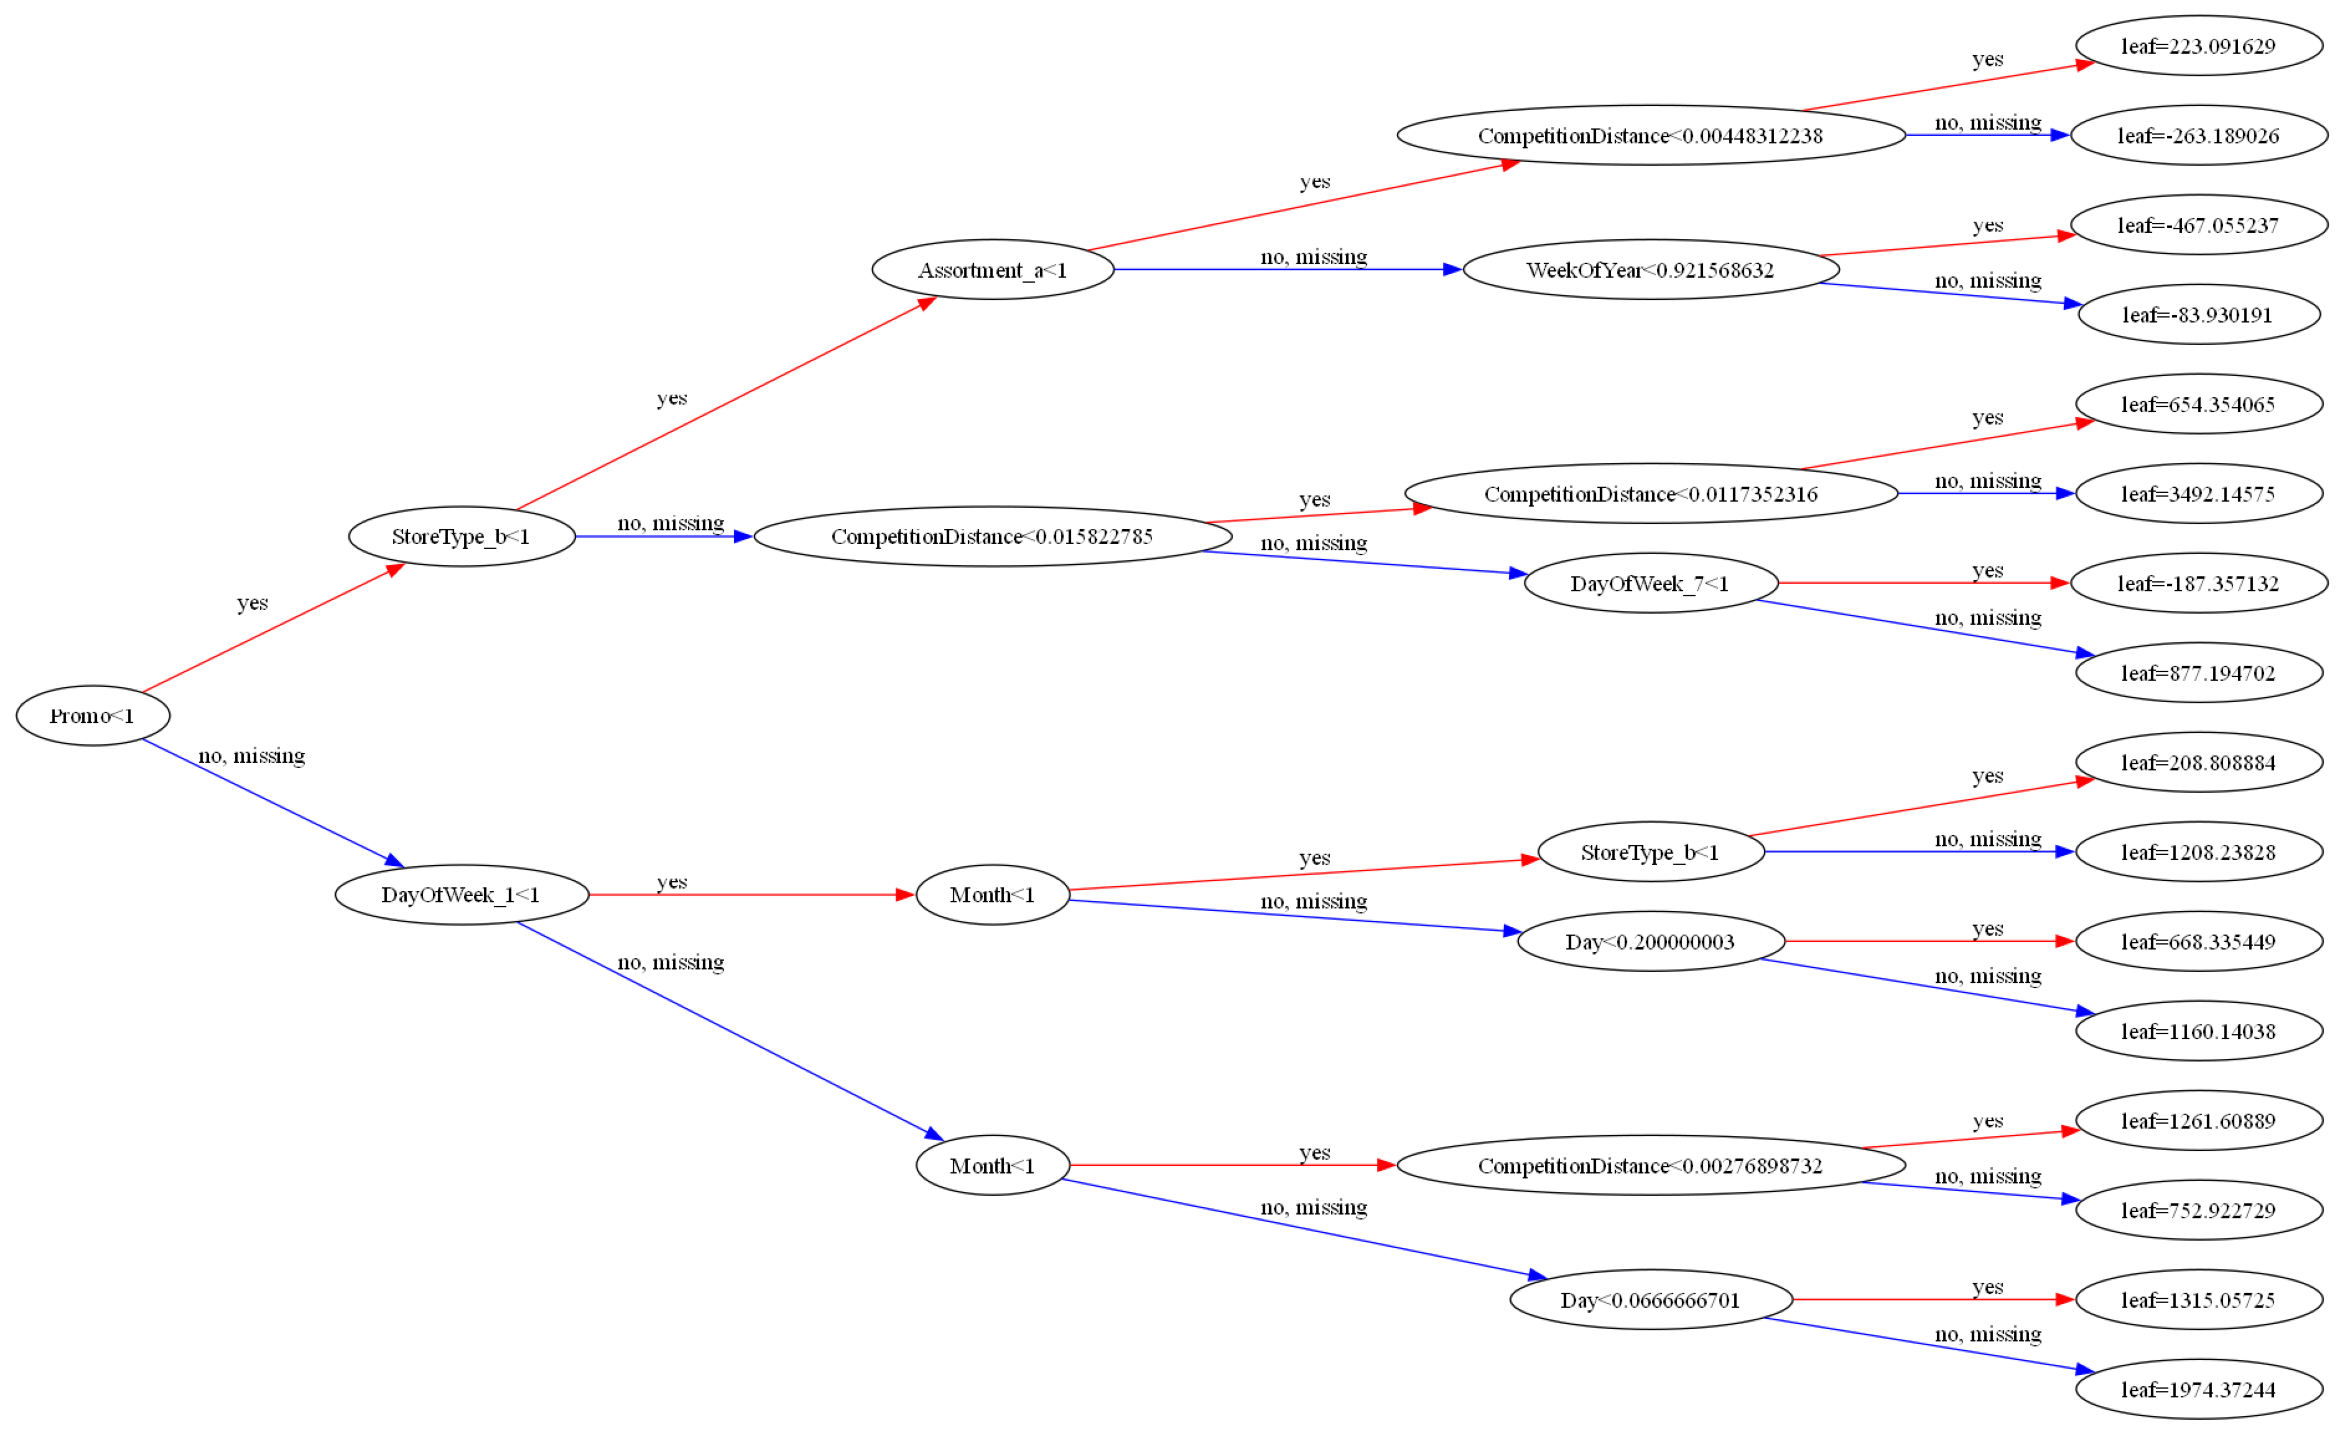

In [71]:
import matplotlib.pyplot as plt
from xgboost import plot_tree

# Coba gambar satu pohon saja
plt.figure(figsize=(20,10))
plot_tree(model, num_trees=0, rankdir='LR')
plt.show()

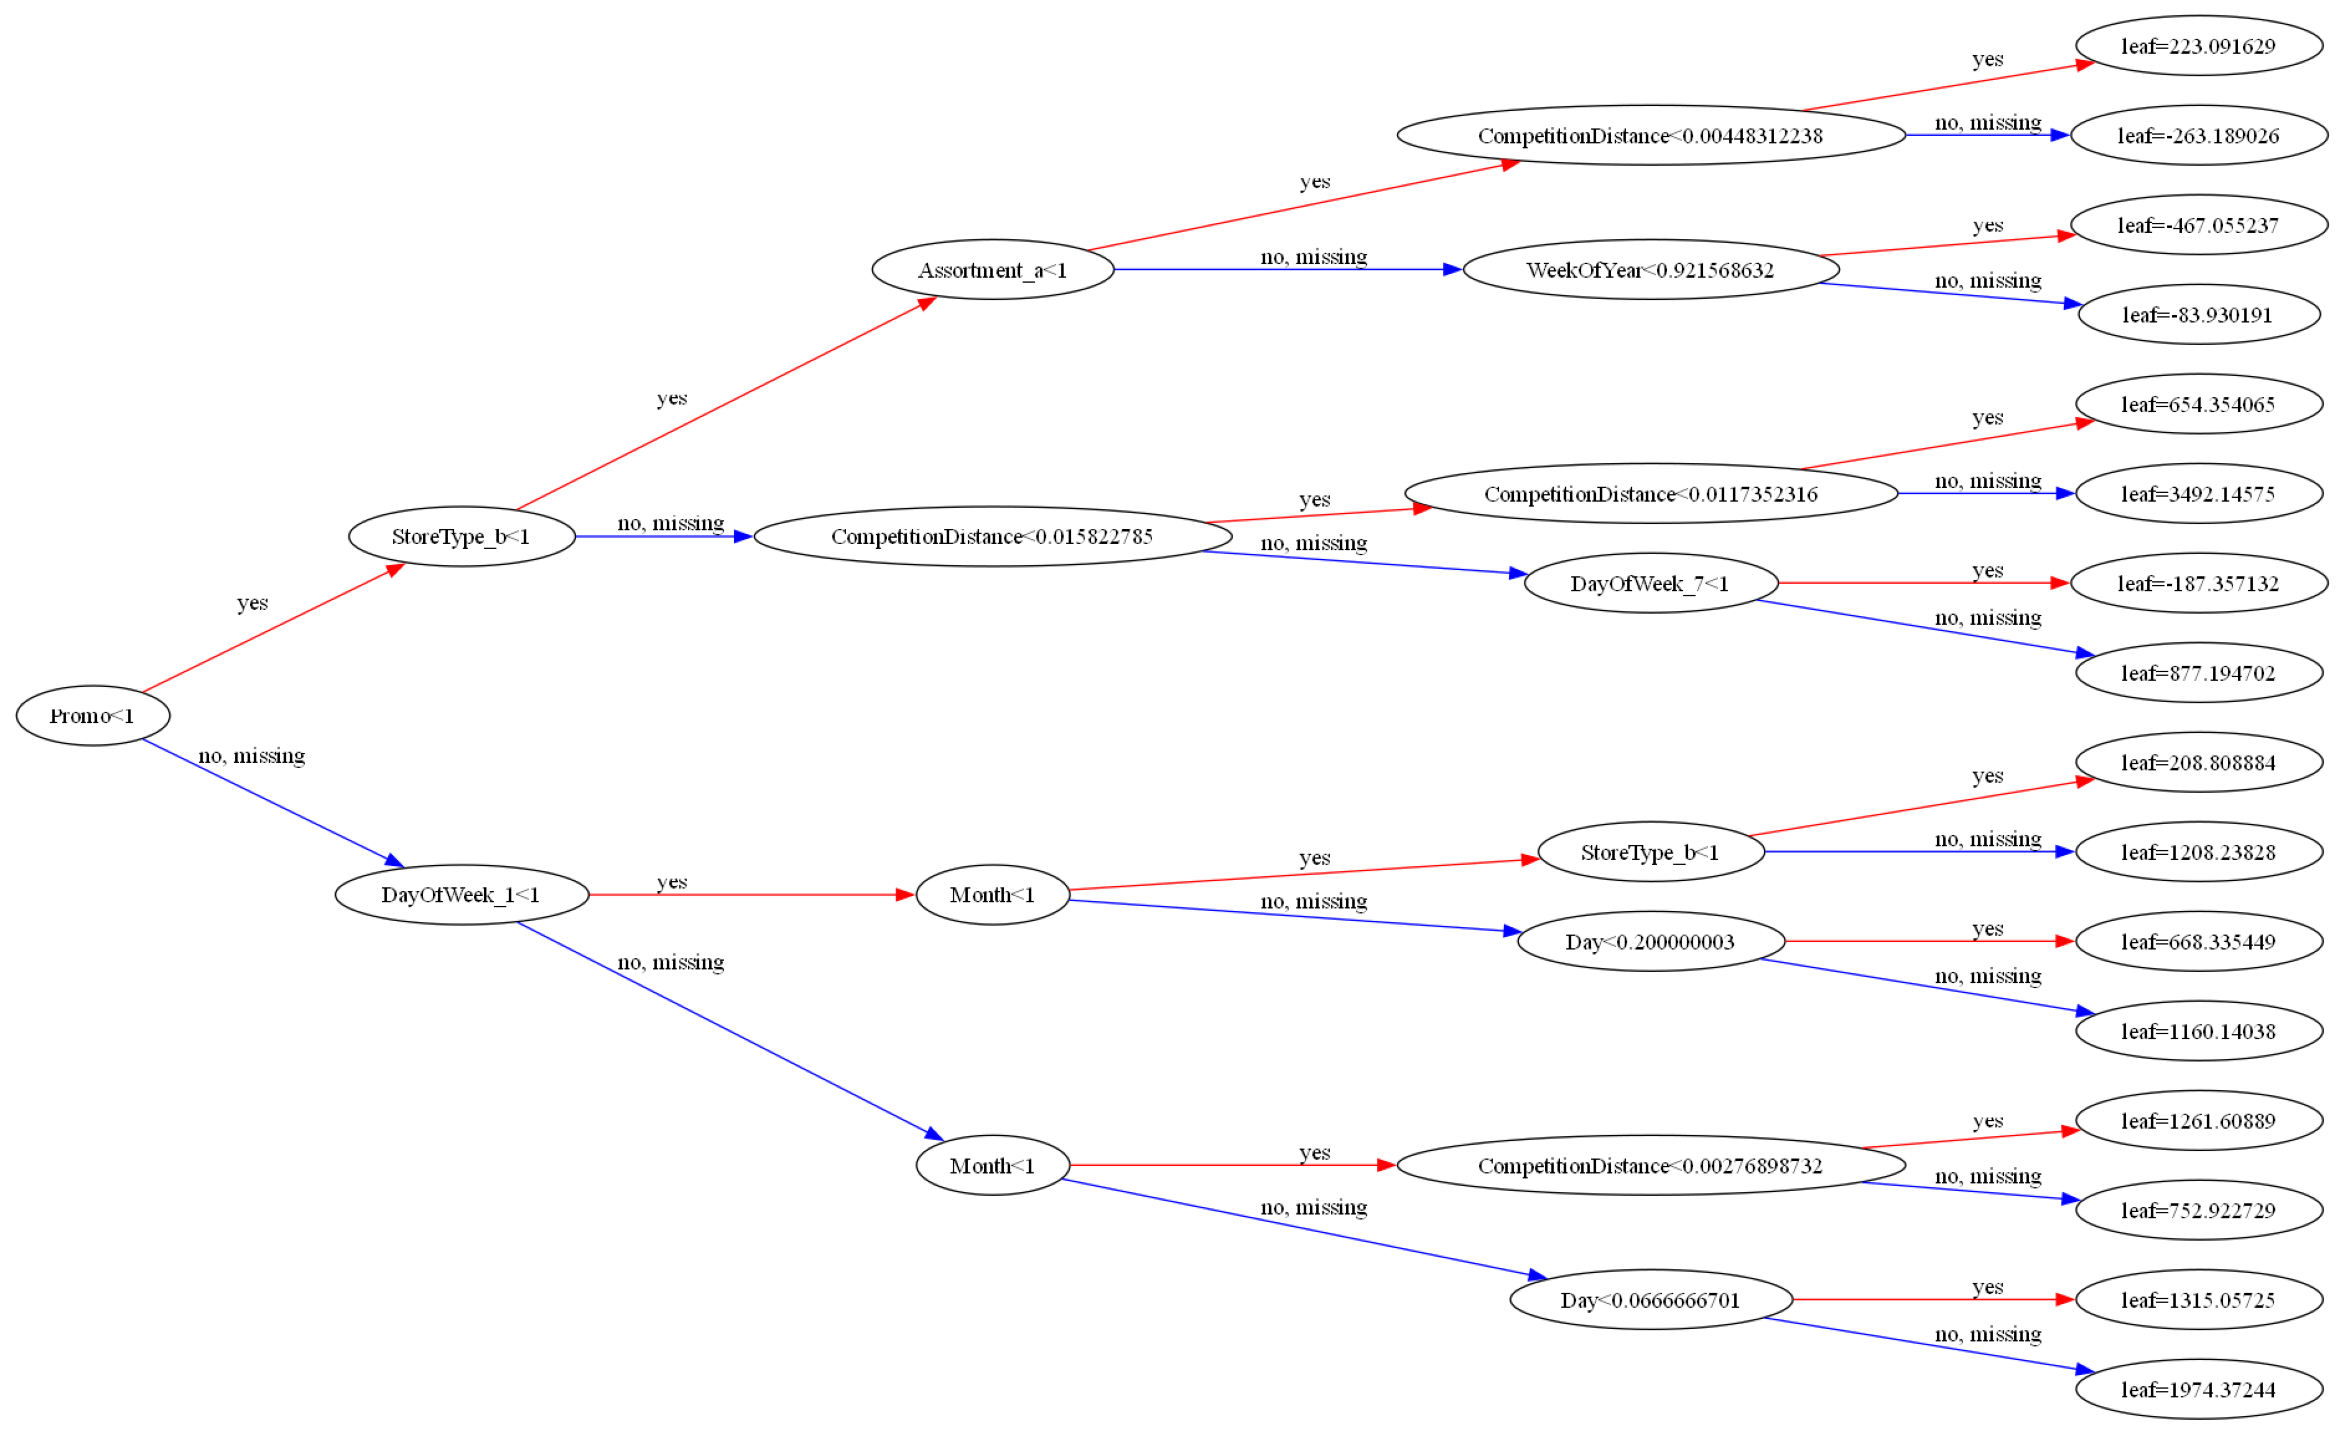

In [72]:
plot_tree(model, rankdir='LR');

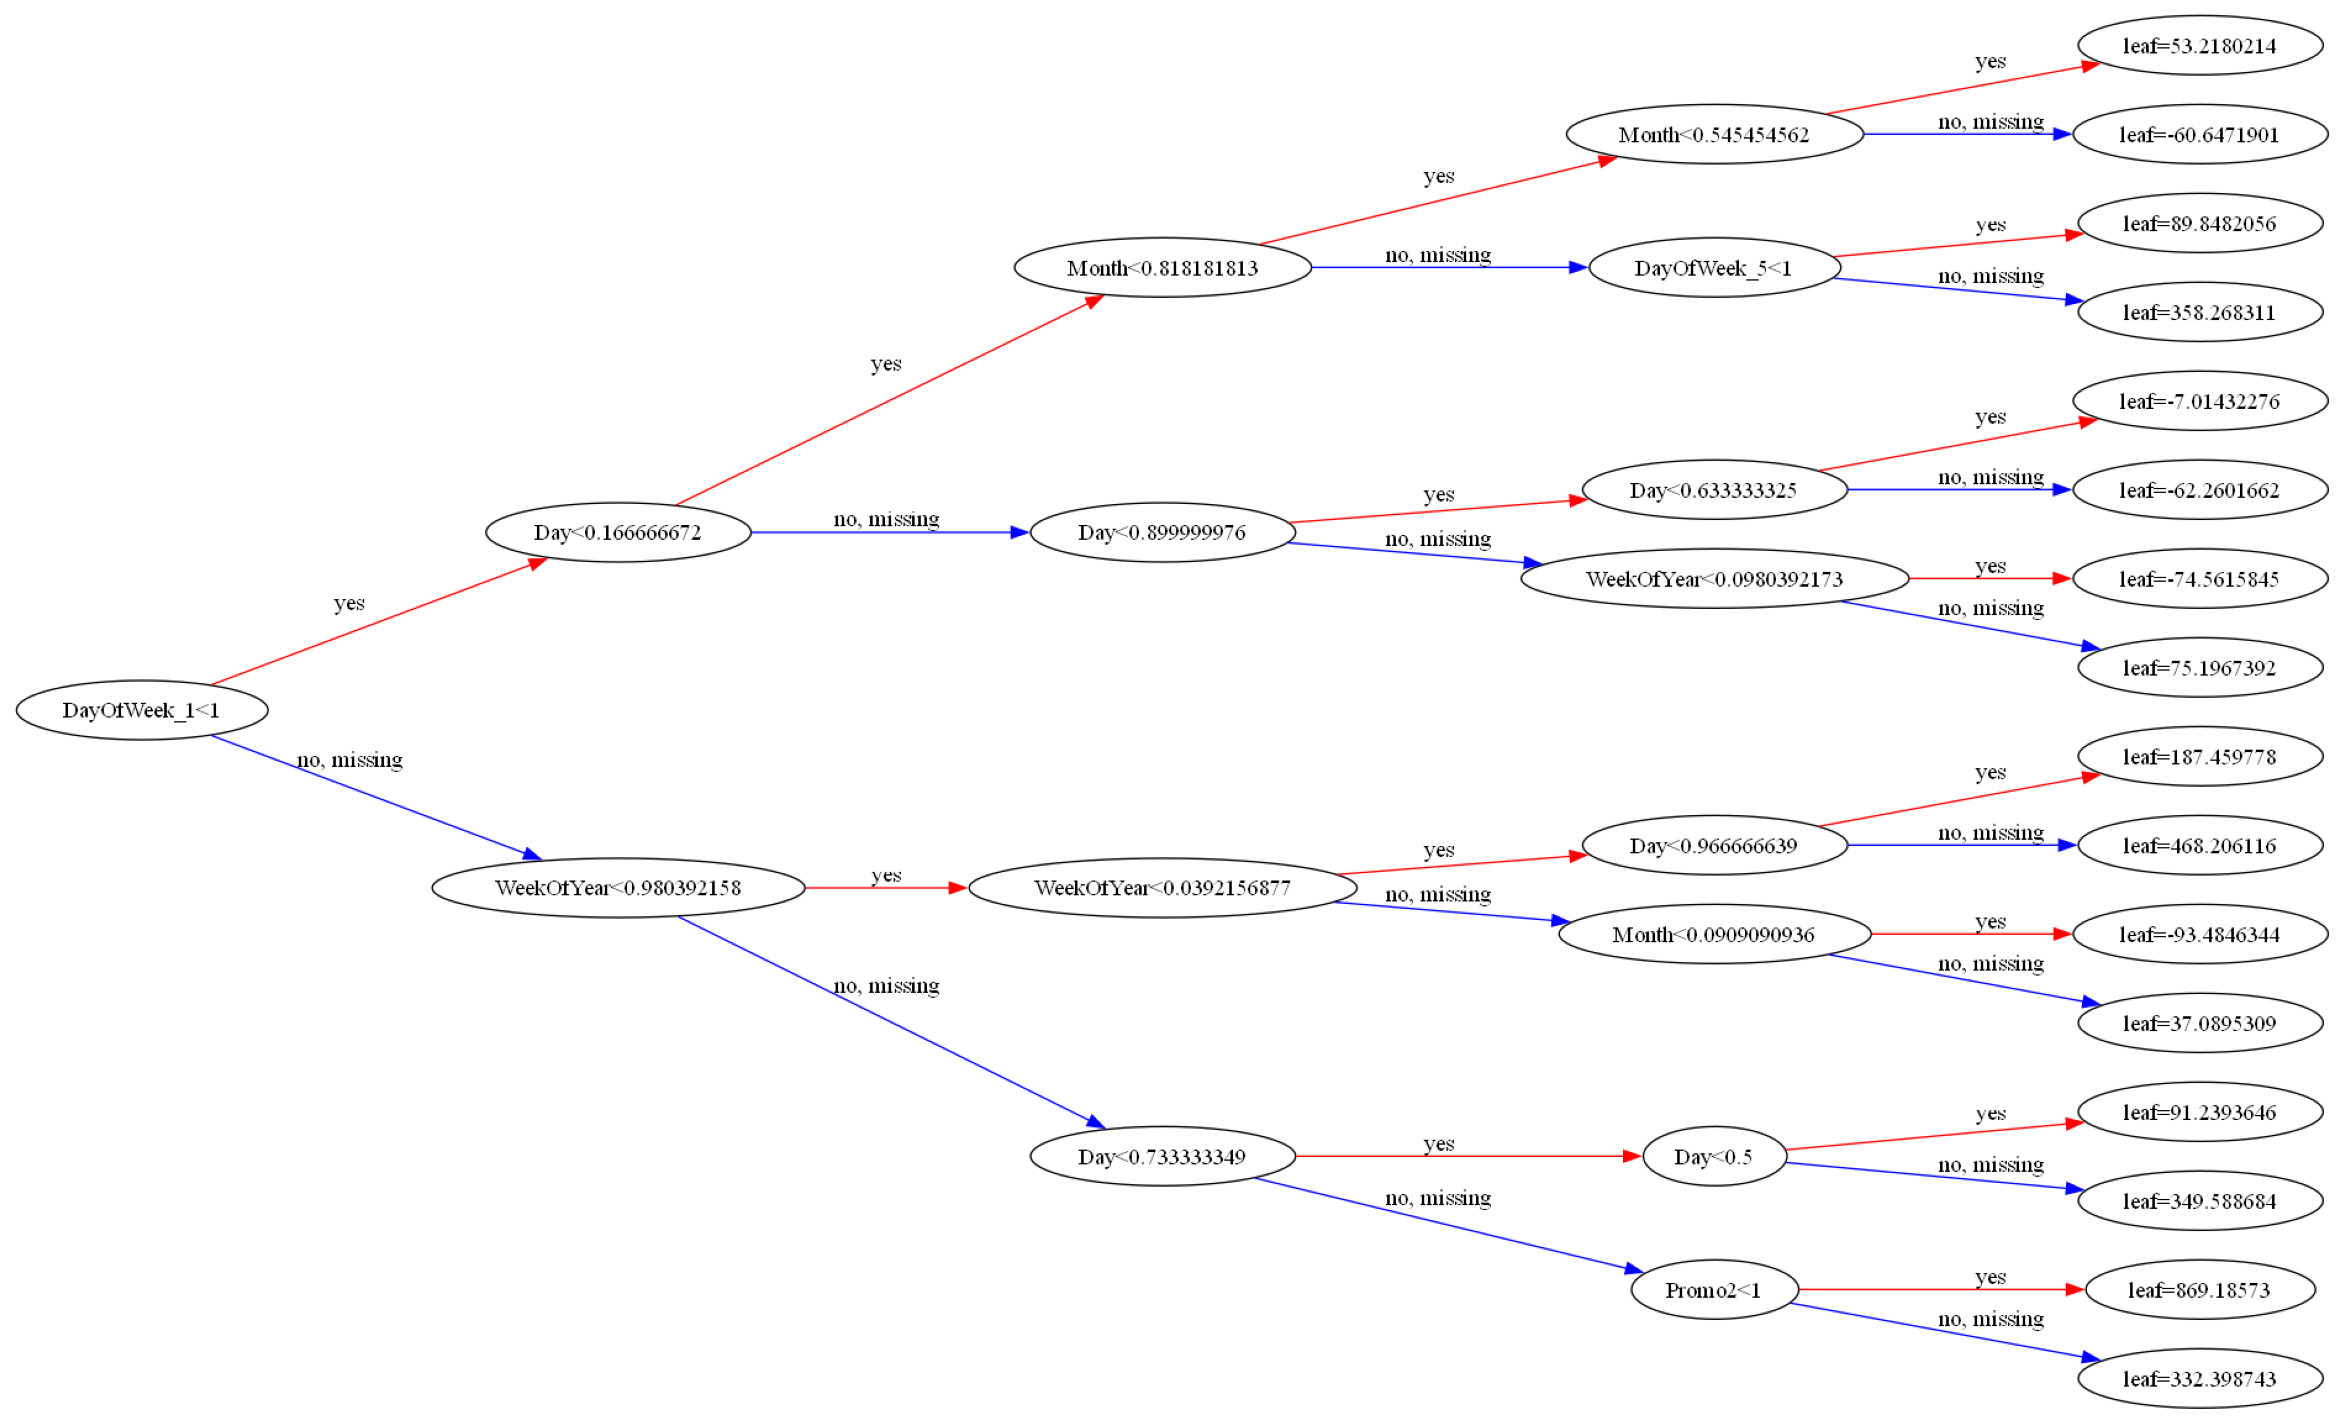

In [73]:
plot_tree(model, rankdir='LR', num_trees=19);

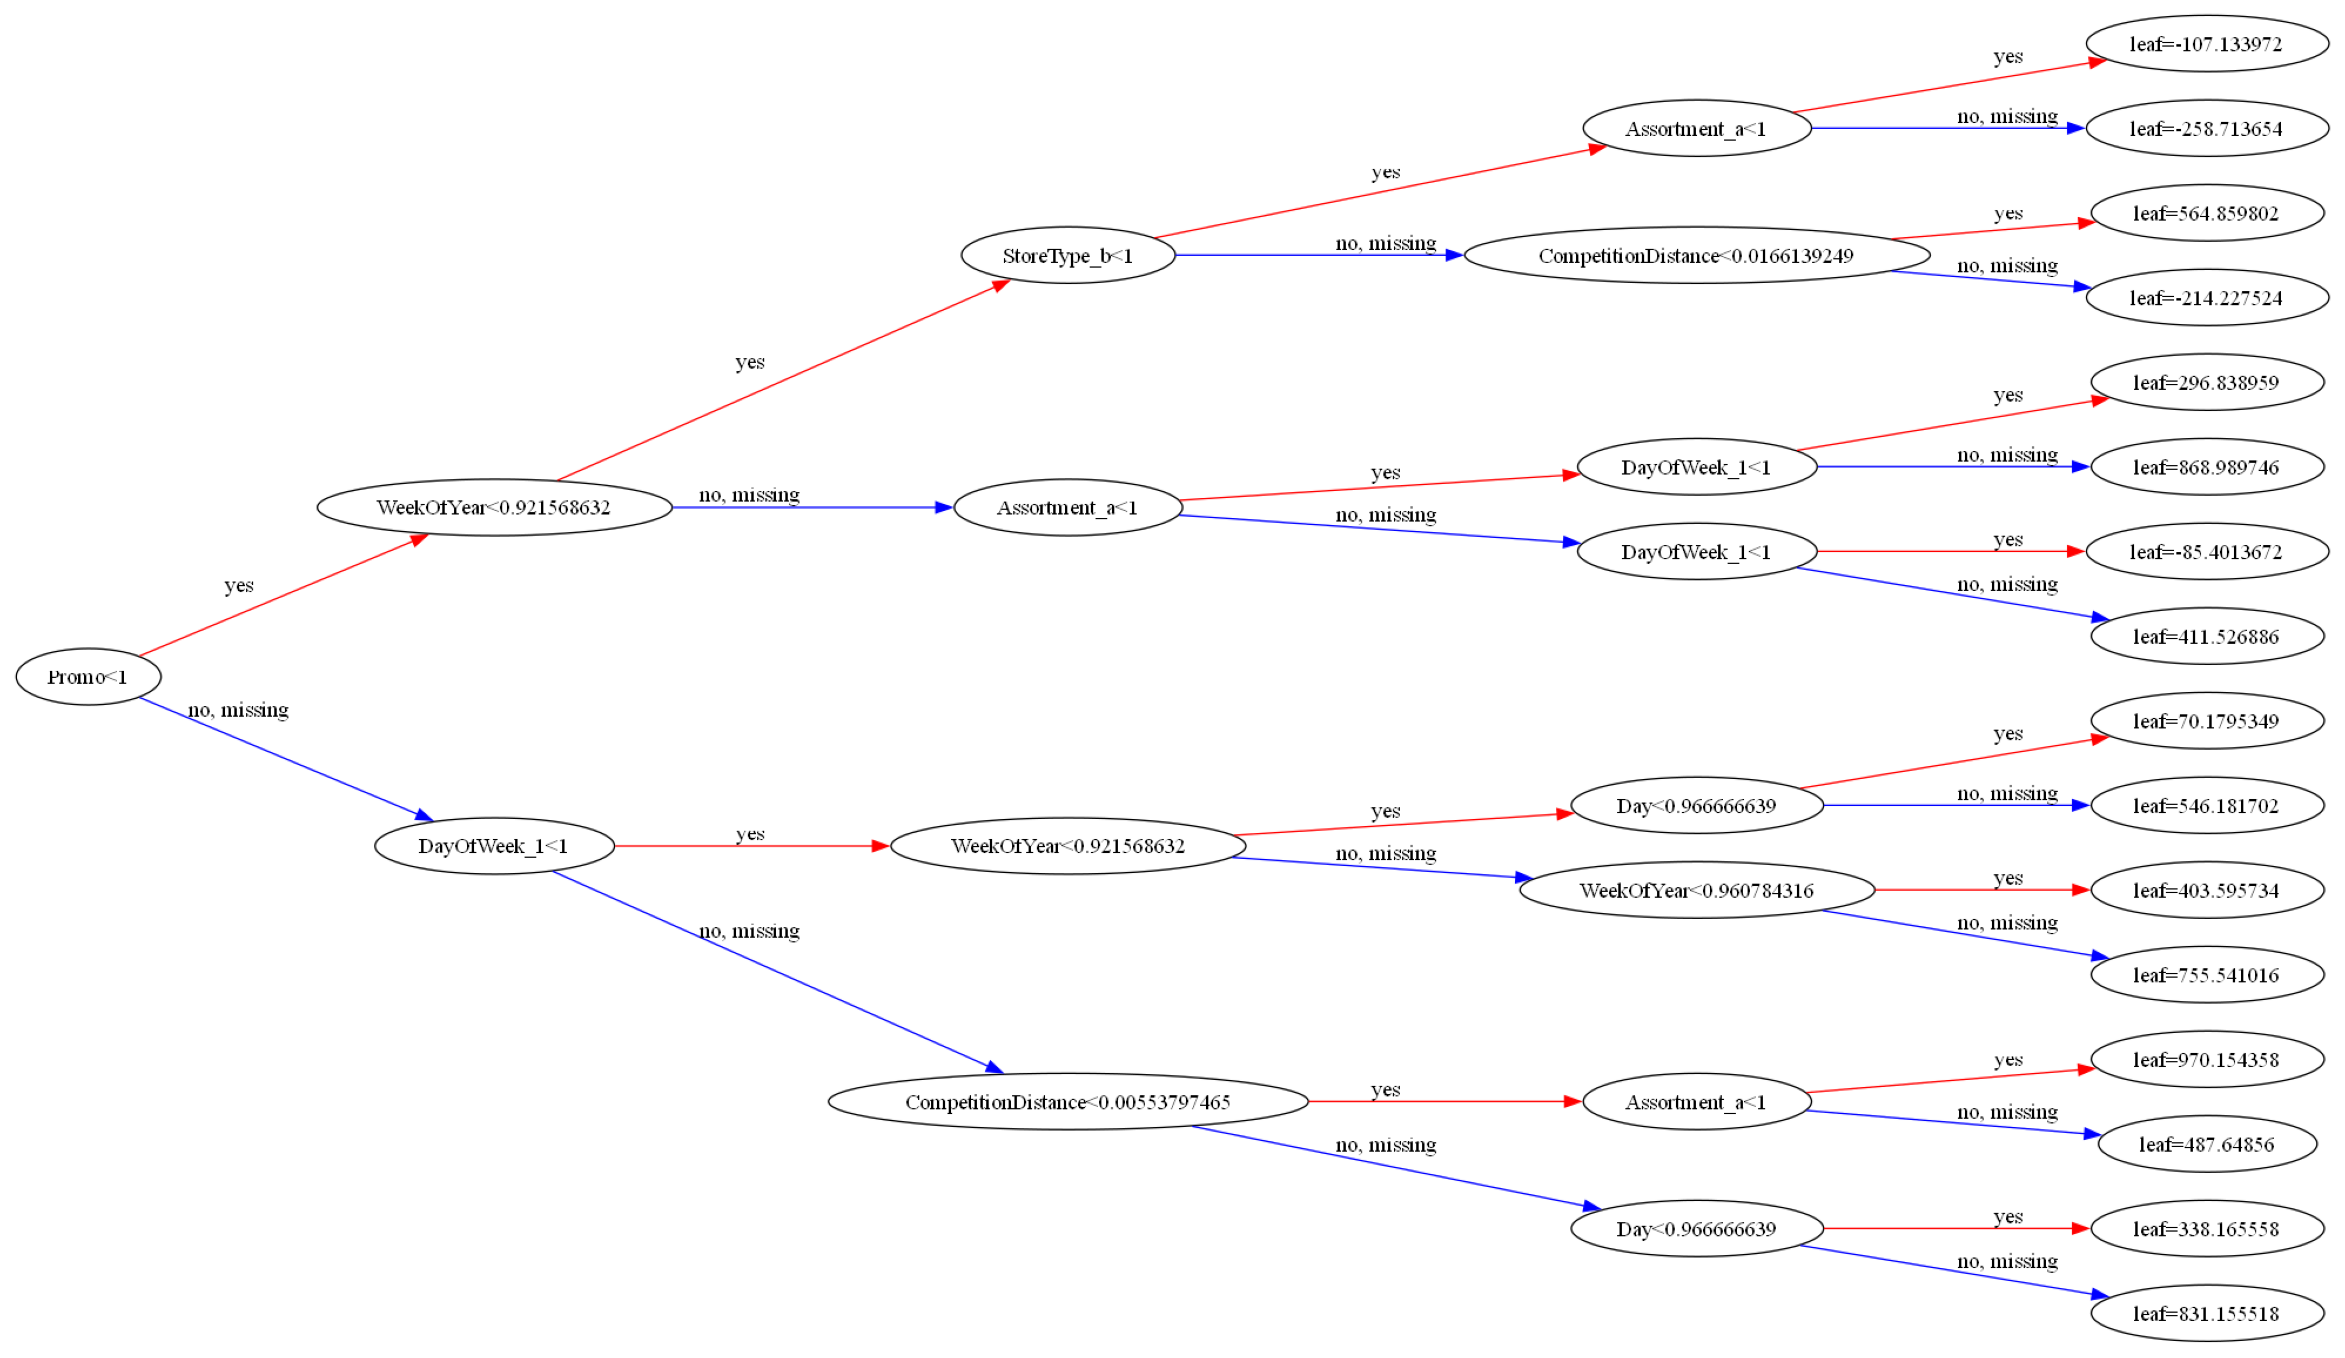

In [74]:
plot_tree(model, rankdir='LR', num_trees=2);

In [75]:
trees = model.get_booster().get_dump()

In [76]:
len(trees)

20

In [77]:
print(trees[0])

0:[Promo<1] yes=1,no=2,missing=2
	1:[StoreType_b<1] yes=3,no=4,missing=4
		3:[Assortment_a<1] yes=7,no=8,missing=8
			7:[CompetitionDistance<0.00448312238] yes=15,no=16,missing=16
				15:leaf=223.091629
				16:leaf=-263.189026
			8:[WeekOfYear<0.921568632] yes=17,no=18,missing=18
				17:leaf=-467.055237
				18:leaf=-83.930191
		4:[CompetitionDistance<0.015822785] yes=9,no=10,missing=10
			9:[CompetitionDistance<0.0117352316] yes=19,no=20,missing=20
				19:leaf=654.354065
				20:leaf=3492.14575
			10:[DayOfWeek_7<1] yes=21,no=22,missing=22
				21:leaf=-187.357132
				22:leaf=877.194702
	2:[DayOfWeek_1<1] yes=5,no=6,missing=6
		5:[Month<1] yes=11,no=12,missing=12
			11:[StoreType_b<1] yes=23,no=24,missing=24
				23:leaf=208.808884
				24:leaf=1208.23828
			12:[Day<0.200000003] yes=25,no=26,missing=26
				25:leaf=668.335449
				26:leaf=1160.14038
		6:[Month<1] yes=13,no=14,missing=14
			13:[CompetitionDistance<0.00276898732] yes=27,no=28,missing=28
				27:leaf=1261.60889
				28:leaf=752.9

### **Features Importance**

In [78]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [80]:
importance_df.head(10)

,feature,importance
1,Promo,0.344243
11,DayOfWeek_1,0.078901
23,StoreType_b,0.074415
5,Promo2,0.050636
25,StoreType_d,0.044852
28,Assortment_c,0.041409
8,Month,0.032310
3,CompetitionDistance,0.032008
10,WeekOfYear,0.031260
22,StoreType_a,0.030250


<Axes: title={'center': 'Feature Importance'}, xlabel='importance', ylabel='feature'>

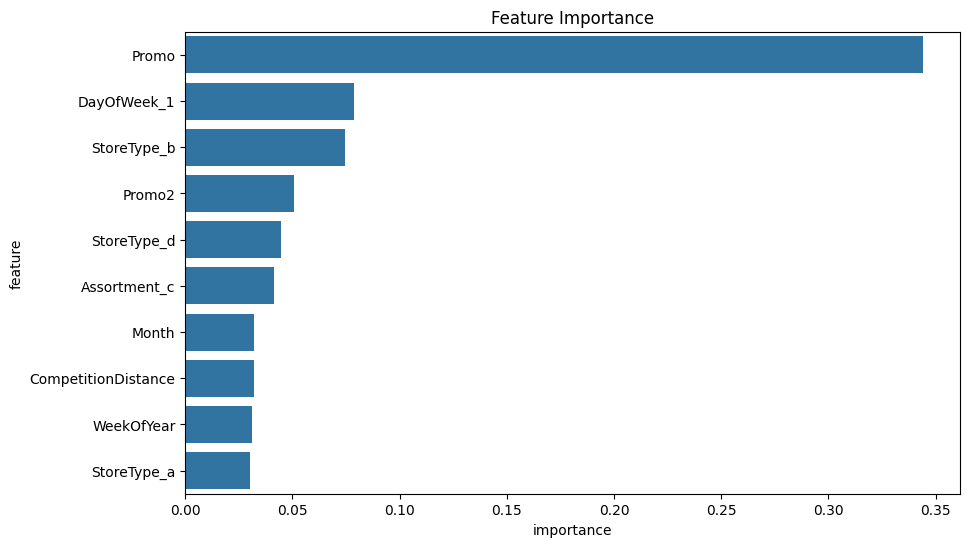

In [81]:
import seaborn as sns
plt.figure(figsize=(10, 6))
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature')

### **K Fold Cross Validation**

In [82]:
from sklearn.model_selection import KFold

In [83]:
def train_and_evaluate(X_train, train_targets, X_val, val_targets, **params):
    model = XGBRegressor(random_state=42, n_jobs=-1, **params)
    model.fit(X_train, train_targets)
    train_rmse = rmse(model.predict(X_train), train_targets)
    val_rmse = rmse(model.predict(X_val), val_targets)
    return model, train_rmse, val_rmse

In [86]:
kfold = KFold(n_splits=5)

In [87]:
models = []

for train_idxs, val_idxs in kfold.split(X):
    X_train, train_targets = X.iloc[train_idxs], targets.iloc[train_idxs]
    X_val, val_targets = X.iloc[val_idxs], targets.iloc[val_idxs]
    model, train_rmse, val_rmse = train_and_evaluate(X_train, 
                                                     train_targets, 
                                                     X_val, 
                                                     val_targets, 
                                                     max_depth=4, 
                                                     n_estimators=20)
    models.append(model)
    print('Train RMSE: {}, Validation RMSE: {}'.format(train_rmse, val_rmse))



Train RMSE: 2394.886474609375, Validation RMSE: 2462.836181640625
Train RMSE: 2401.240478515625, Validation RMSE: 2450.412353515625
Train RMSE: 2411.892822265625, Validation RMSE: 2391.591064453125
Train RMSE: 2347.00244140625, Validation RMSE: 2439.3330078125
Train RMSE: 2397.846435546875, Validation RMSE: 2466.51220703125


In [88]:
import numpy as np
def predict_avg(models, inputs):
    return np.mean([model.predict(inputs) for model in models], axis=0)

In [89]:
preds = predict_avg(models, X)

In [90]:
preds

array([8057.5195, 7592.8687, 8729.01  , ..., 7434.3735, 7962.121 ,
       9660.862 ], dtype=float32)

### **Hyperparameter Tuning and Regularization**

In [91]:
model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=20,
             n_jobs=-1, num_parallel_tree=None, ...)

In [92]:
def test_params_kfold(n_splits, **params):
    train_rmses, val_rmses, models = [], [], []
    kfold = KFold(n_splits)
    for train_idxs, val_idxs in kfold.split(X):
        X_train, train_targets = X.iloc[train_idxs], targets.iloc[train_idxs]
        X_val, val_targets = X.iloc[val_idxs], targets.iloc[val_idxs]
        model, train_rmse, val_rmse = train_and_evaluate(X_train, train_targets, X_val, val_targets, **params)
        models.append(model)
        train_rmses.append(train_rmse)
        val_rmses.append(val_rmse)
    print('Train RMSE: {}, Validation RMSE: {}'.format(np.mean(train_rmses), np.mean(val_rmses)))
    return models

In [93]:
from sklearn.model_selection import train_test_split

In [94]:
X_train, X_val, train_targets, val_targets = train_test_split(X, targets, test_size=0.1)

In [95]:
def test_params(**params):
    model = XGBRegressor(n_jobs=-1, random_state=42, **params)
    model.fit(X_train, train_targets)
    train_rmse = rmse(model.predict(X_train), train_targets)
    val_rmse = rmse(model.predict(X_val), val_targets)
    print('Train RMSE: {}, Validation RMSE: {}'.format(train_rmse, val_rmse))

In [96]:
test_params(n_estimators=10)

Train RMSE: 2370.452880859375, Validation RMSE: 2372.797119140625


In [97]:
test_params(n_estimators=20)

Train RMSE: 2122.645751953125, Validation RMSE: 2127.496826171875


In [98]:
test_params(n_estimators=30)

Train RMSE: 1871.9012451171875, Validation RMSE: 1878.0284423828125


In [99]:
test_params(n_estimators=100)

Train RMSE: 1164.551513671875, Validation RMSE: 1175.610107421875


In [100]:
test_params(n_estimators=240)

Train RMSE: 900.1018676757812, Validation RMSE: 926.2067260742188


In [101]:
test_params(n_estimators=340)

Train RMSE: 832.0012817382812, Validation RMSE: 864.8790283203125


In [102]:
test_params(max_depth=2)

Train RMSE: 2378.72607421875, Validation RMSE: 2378.596923828125


In [103]:
test_params(max_depth=5)

Train RMSE: 1441.138916015625, Validation RMSE: 1447.519287109375


In [104]:
test_params(max_depth=4)

Train RMSE: 1739.7418212890625, Validation RMSE: 1745.1422119140625


In [105]:
test_params(max_depth=10)

Train RMSE: 668.787841796875, Validation RMSE: 779.1627197265625


In [106]:
test_params(n_estimators=50, learning_rate=0.01)

Train RMSE: 2790.0322265625, Validation RMSE: 2784.354736328125


In [107]:
test_params(n_estimators=50, learning_rate=0.1)

Train RMSE: 2187.573974609375, Validation RMSE: 2189.26123046875


In [108]:
test_params(n_estimators=50, learning_rate=0.3)

Train RMSE: 1547.17333984375, Validation RMSE: 1553.53076171875


In [109]:
test_params(n_estimators=50, learning_rate=0.9)

Train RMSE: 1145.0299072265625, Validation RMSE: 1159.3524169921875


In [110]:
test_params(n_estimators=50, learning_rate=0.99)

Train RMSE: 1171.3975830078125, Validation RMSE: 1192.5863037109375


In [111]:
test_params(booster='gblinear')

Train RMSE: 2727.389892578125, Validation RMSE: 2723.27783203125


In [112]:
test_params(booster='gbtree')

Train RMSE: 1164.551513671875, Validation RMSE: 1175.610107421875


In [113]:
test_params(booster='dart')

Train RMSE: 1164.551513671875, Validation RMSE: 1175.610107421875


### **Putting it Together and Making Predictions**

In [114]:
model = XGBRegressor(n_jobs=-1, random_state=42, n_estimators=1000, 
                     learning_rate=0.2, max_depth=10, subsample=0.9, 
                     colsample_bytree=0.7)

In [115]:
%%time
model.fit(X, targets)

CPU times: total: 6min 20s
Wall time: 37.6 s


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [116]:
test_preds = model.predict(X_test)

In [117]:
submission_df['Sales']  = test_preds

In [118]:
test_df.Open.isna().sum()

np.int64(11)

In [119]:
submission_df['Sales'] = submission_df['Sales'] * test_df.Open.fillna(1.)

In [120]:
submission_df

,Id,Sales
0,1,3953.359863
1,2,7986.175781
2,3,9365.528320
3,4,7680.842773
4,5,7304.307617
...,...,...
41083,41084,3087.688965
41084,41085,8228.096680
41085,41086,6916.906738
41086,41087,24140.535156


In [121]:
submission_df.to_csv('submission.csv', index=None)